**Problem statement: Build and evaluate a hybrid recommendation engine (content-based+ collaborative filtering) for an e-commerce platform using product metadata and
user behavior data.**

**Section A:**

 Data Understanding & Cleaning: Understand the dataset like a data scientist in a product analytics team.
Summarize the dataset:
Number of unique users, products, and reviews
Top 5 categories by number of products
Price range and discount insights
Clean and preprocess the data:
Convert prices to numeric
Parse categories into hierarchy levels
Normalize rating scores and count outliers or Create derived features like price_difference, value_for_money_score, weighted ratings.
Handle missing values or anomalies
Remove duplicates, invalid records
Handle missing ratings/reviews with appropriate strategy

**Section B:**

Exploratory Data Analysis: Think like a product analyst trying to identify buying patterns
Visualize:
Most reviewed products Visualize top 10 categories by number of products.
Average rating per category
Discounts vs actual price correlation
User Engagement Insights (5 marks)
○ Which products have high ratings but low review counts?
○ Are highly rated products also heavily reviewed?
Create 3 actionable insights for Amazon’s product strategy based on EDA.

**Section C:**

Content-Based Filtering: Act like a content engineer personalizing user feeds based on product metadata.
Vectorize product text (about_product + product_name) using:
TF-IDF or embeddings
Build a product similarity matrix
Recommend top 5 similar products to:
A new product with no reviews
A product with high user dropout (bad ratings)
Add category, price, and discount to enhance content vectors
Evaluate recommendations:
How diverse and relevant are the content-based results?

**Section D:**

Collaborative Filtering (User–Item) : Now you're a machine learning engineer building smart recommendations using user behavior.
Create a user-item matrix using user_id, product_id, and rating.
Apply: User-User Collaborative Filtering (cosine similarity) OR Item-Item Collaborative Filtering (cosine or Pearson)
Recommend top 5 unseen products per user

**Section E:**

 Hybrid Recommender (Content + Collaborative) : Step into the role of a senior ML engineer combining models for better performance.
Design a hybrid strategy:
Score fusion: 0.6 * CF_score + 0.4 * Content_score
Compare recommendation quality of hybrid vs individual methods.
Evaluate hybrid system on:
A cold-start product (new product)
A cold-start user (few reviews)
Suggest how to improve hybrid performance further using real-world constraints like:
Popularity
Recent purchases
Product availability

**Section F:**

 Bonus: Business Strategy & Deployment
Which model works best for new users ?
Which model works best for returning users ?
How can we recommend products with no ratings ?
How would you deploy this system in production?Mention tools/technologies.

What KPIs should Amazon track to measure success?

🔹 Section : Load Data Understanding

In [ ]:

!pip install gdown
import gdown

# ── Standard Library ─────────────────────────────────
import os
import zipfile

# ── Data ─────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── ML ───────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error



Download file

In [ ]:

file_id = "1OA0wOG1epBxHAMNXun7kwNr_QsupUMzj"
url = f"https://drive.google.com/uc?id={file_id}"

output = "amazon_dataset.zip"
gdown.download(url, output, quiet=False)

print("Download Complete!")

Downloading...
From: https://drive.google.com/uc?id=1OA0wOG1epBxHAMNXun7kwNr_QsupUMzj
To: /content/amazon_dataset.zip
100%|██████████| 2.04M/2.04M [00:00<00:00, 32.8MB/s]

Download Complete!


UNZIP FILE

In [ ]:

zip_file_name = "/content/amazon_dataset.zip"

with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall("AmazonDataset")

print("Files extracted successfully!")

Files extracted successfully!


Load CSV

In [ ]:
csv_file = "/content/AmazonDataset/amazon.csv"
df = pd.read_csv(csv_file)

df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


##**Section A: Data Understanding & Cleaning:**

In [ ]:
df.shape
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


Unique Users & Products

Why This Matters

High users + low reviews → sparse data

High reviews per product → strong collaborative filtering

Few reviews per user → cold-start risk



In [ ]:
num_users = df['user_id'].nunique()
num_products = df['product_id'].nunique()
num_reviews = df['review_id'].nunique()

print("Unique Users:", num_users)
print("Unique Products:", num_products)
print("Total Reviews:", num_reviews)

Unique Users: 1194
Unique Products: 1351
Total Reviews: 1194


Interaction Density

Business Insight

If:

Most users review only 1 product → sparse matrix

Few products have most reviews → popularity bias


Reviews Per User

In [ ]:
reviews_per_user = df.groupby('user_id')['review_id'].count()
reviews_per_user.describe()

,review_id
count,1194.000000
mean,1.226968
std,0.772262
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,10.000000


Reviews Per Product

In [ ]:
reviews_per_product = df.groupby('product_id')['review_id'].count()
reviews_per_product.describe()

,review_id
count,1351.000000
mean,1.084382
std,0.331529
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,3.000000


Basic Cleaning and remove duplicates

In [ ]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Remove rows with missing product_id or user_id
df = df.dropna(subset=['product_id', 'user_id'])

df.shape

(1465, 16)

Convert Prices to Numeric

In [ ]:
df['discounted_price'] = (
    df['discounted_price']
    .astype(str)
    .str.replace('₹','')
    .str.replace(',','')
)

df['actual_price'] = (
    df['actual_price']
    .astype(str)
    .str.replace('₹','')
    .str.replace(',','')
)

df['discounted_price'] = pd.to_numeric(df['discounted_price'], errors='coerce')
df['actual_price'] = pd.to_numeric(df['actual_price'], errors='coerce')

Convert Discount %

In [ ]:
df['discount_percentage'] = (
    df['discount_percentage']
    .astype(str)
    .str.replace('%','')
)

df['discount_percentage'] = pd.to_numeric(df['discount_percentage'], errors='coerce')

In [ ]:
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.0,1099.0,64,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,199.0,349.0,43,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,199.0,1899.0,90,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,329.0,699.0,53,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,154.0,399.0,61,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


**Clean Rating Columns**

In [ ]:
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df['rating_count'] = pd.to_numeric(df['rating_count'], errors='coerce')

# Remove invalid ratings
df = df[df['rating'].between(1,5)]

Parse Category Hierarchy

In [ ]:
# Count how many levels each row has
df['category_depth'] = df['category'].apply(lambda x: len(str(x).split('|')))

# See distribution
df['category_depth'].value_counts()


,count
category_depth,
4,778
5,437
3,157
6,71
7,13
2,8


In [ ]:
unique_categories = df['category'].str.split('|').explode().unique()
print(unique_categories)

['Computers&Accessories' 'Accessories&Peripherals' 'Cables&Accessories'
 'Cables' 'USBCables' 'NetworkingDevices' 'NetworkAdapters'
 'WirelessUSBAdapters' 'Electronics' 'HomeTheater,TV&Video' 'Accessories'
 'HDMICables' 'Televisions' 'SmartTelevisions' 'RemoteControls'
 'StandardTelevisions' 'TVMounts,Stands&Turntables' 'TVWall&CeilingMounts'
 'RCACables' 'HomeAudio' 'SpeakerAccessories' 'Mounts' 'OpticalCables'
 'Projectors' 'Adapters' 'SatelliteEquipment' 'SatelliteReceivers'
 'DVICables' 'SpeakerCables' 'MediaStreamingDevices' 'StreamingClients'
 'AVReceivers&Amplifiers' 'Speakers' 'TowerSpeakers' '3DGlasses'
 'WearableTechnology' 'SmartWatches' 'Mobiles&Accessories'
 'MobileAccessories' 'Chargers' 'PowerBanks' 'Smartphones&BasicMobiles'
 'Smartphones' 'MemoryCards' 'MicroSD' 'BasicMobiles'
 'Headphones,Earbuds&Accessories' 'Headphones' 'In-Ear'
 'AutomobileChargers' 'AutomobileAccessories' 'Cradles' 'WallChargers'
 'Cables&Adapters' 'OTGAdapters' 'Photo&VideoAccessories' 'Tripods'


In [ ]:
max_depth = df['category_depth'].max()
print("Maximum category levels:", max_depth)

Maximum category levels: 7


In [ ]:
max_levels = df['category_depth'].max()

cat_cols = [f'cat_lvl{i+1}' for i in range(max_levels)]

df[cat_cols] = df['category'].str.split('|', expand=True)

# Strip spaces
for col in cat_cols:
    df[col] = df[col].str.strip()


In [ ]:
for col in cat_cols:
    print(col, "missing:", df[col].isna().sum())

cat_lvl1 missing: 0
cat_lvl2 missing: 0
cat_lvl3 missing: 8
cat_lvl4 missing: 165
cat_lvl5 missing: 943
cat_lvl6 missing: 1380
cat_lvl7 missing: 1451


In [ ]:
df['category_depth'].value_counts()

,count
category_depth,
4,778
5,437
3,157
6,71
7,13
2,8


In [ ]:
for col in ['cat_lvl1','cat_lvl2','cat_lvl3','cat_lvl4','cat_lvl5']:
    df[col] = df[col].str.replace('&', ' & ')

**Top 5 Categories Visualization**

Top 5 Categories by Product Count:
cat_lvl1
Electronics                490
Home & Kitchen             447
Computers & Accessories    375
OfficeProducts              31
MusicalInstruments           2


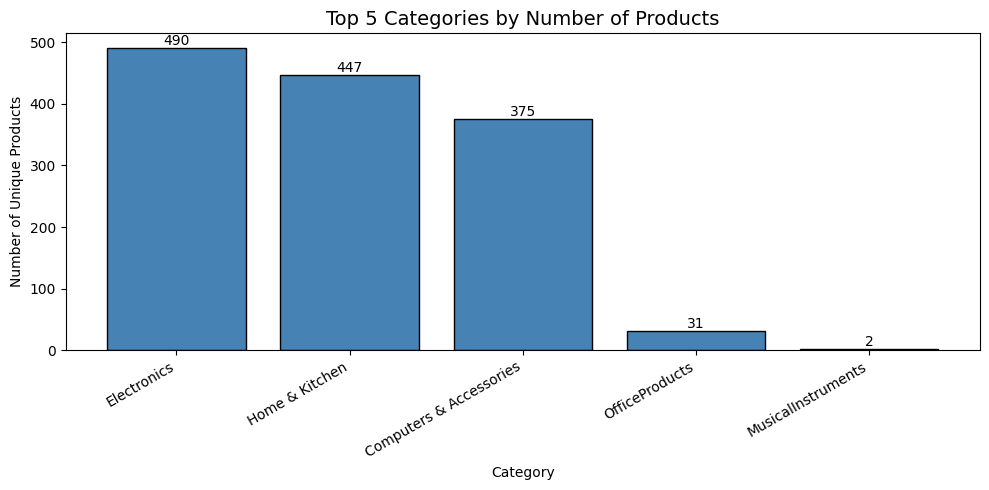

In [ ]:
# ── Top 5 Categories by Number of Products ──────────────────────────────────
top5_categories = (
    df.groupby('cat_lvl1')['product_id']
    .nunique()
    .sort_values(ascending=False)
    .head(5)
)

print("Top 5 Categories by Product Count:")
print(top5_categories.to_string())

plt.figure(figsize=(10, 5))
bars = plt.bar(top5_categories.index, top5_categories.values, color='steelblue', edgecolor='black')
plt.title("Top 5 Categories by Number of Products", fontsize=14)
plt.xlabel("Category")
plt.ylabel("Number of Unique Products")
plt.xticks(rotation=30, ha='right')

# Add value labels on top of each bar
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(int(bar.get_height())), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

**2. Price Range Summary & Distribution**

=== Price Range Insights ===
Discounted Price  →  Min: ₹39  |  Max: ₹77,990  |  Median: ₹799
Actual Price      →  Min: ₹39  |  Max: ₹139,900  |  Median: ₹1,650

Products per Price Bucket:
price_bucket
<₹500       576
₹500-1K     252
₹1K-5K      430
₹5K-10K      84
₹10K-50K    119
>₹50K         3


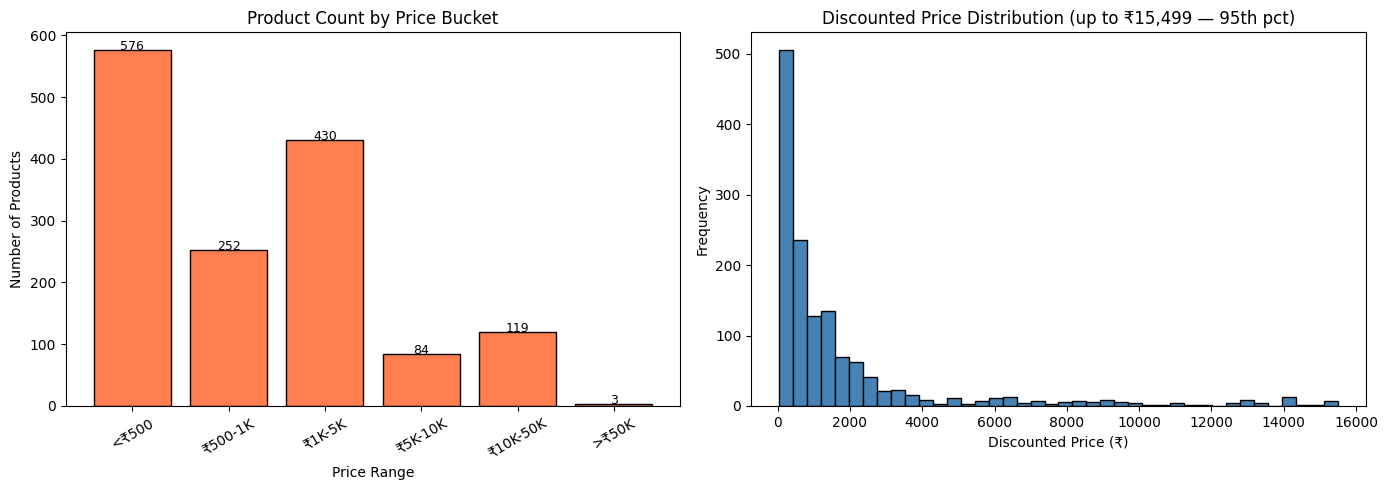

In [ ]:
# ── Price Range Summary & Distribution ──────────────────────────────────────

# Summary stats
print("=== Price Range Insights ===")
print(f"Discounted Price  →  Min: ₹{df['discounted_price'].min():,.0f}  |  "
      f"Max: ₹{df['discounted_price'].max():,.0f}  |  "
      f"Median: ₹{df['discounted_price'].median():,.0f}")
print(f"Actual Price      →  Min: ₹{df['actual_price'].min():,.0f}  |  "
      f"Max: ₹{df['actual_price'].max():,.0f}  |  "
      f"Median: ₹{df['actual_price'].median():,.0f}")

# Price bucket analysis
bins   = [0, 500, 1000, 5000, 10000, 50000, float('inf')]
labels = ['<₹500', '₹500-1K', '₹1K-5K', '₹5K-10K', '₹10K-50K', '>₹50K']

df['price_bucket'] = pd.cut(df['discounted_price'], bins=bins, labels=labels)

df_clean_price = df.dropna(subset=['discounted_price'])
df_clean_price['price_bucket'] = pd.cut(df_clean_price['discounted_price'], bins=bins, labels=labels)
bucket_counts = df_clean_price['price_bucket'].value_counts().sort_index()

print("\nProducts per Price Bucket:")
print(bucket_counts.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: price bucket bar chart
axes[0].bar(bucket_counts.index.astype(str), bucket_counts.values,
            color='coral', edgecolor='black')
axes[0].set_title("Product Count by Price Bucket")
axes[0].set_xlabel("Price Range")
axes[0].set_ylabel("Number of Products")
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(bucket_counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontsize=9)

# Right: discounted price distribution (capped at 95th percentile for readability)
price_cap = df['discounted_price'].quantile(0.95)
axes[1].hist(df[df['discounted_price'] <= price_cap]['discounted_price'],
             bins=40, color='steelblue', edgecolor='black')
axes[1].set_title(f"Discounted Price Distribution (up to ₹{price_cap:,.0f} — 95th pct)")
axes[1].set_xlabel("Discounted Price (₹)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

**Missing Values Strategy — Explicit Decision per Column**

In [ ]:
# ── Missing Values Strategy ──────────────────────────────────────────────────

print("Missing values BEFORE treatment:")
print(df.isna().sum()[df.isna().sum() > 0])

# --- Text columns: fill with empty string (needed for TF-IDF later) ---
text_cols = ['about_product', 'review_content', 'review_title',
             'product_name', 'user_name']
for col in text_cols:
    missing = df[col].isna().sum()
    if missing > 0:
        df[col] = df[col].fillna('')
        print(f"  ✔ '{col}': {missing} nulls → filled with empty string")

# --- URL columns: fill with placeholder (not used in modeling) ---
url_cols = ['img_link', 'product_link']
for col in url_cols:
    missing = df[col].isna().sum()
    if missing > 0:
        df[col] = df[col].fillna('unknown')
        print(f"  ✔ '{col}': {missing} nulls → filled with 'unknown'")

# --- Numeric price columns: fill with median (avoid distorting distributions) ---
for col in ['discounted_price', 'actual_price', 'discount_percentage']:
    missing = df[col].isna().sum()
    if missing > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"  ✔ '{col}': {missing} nulls → filled with median (₹{median_val:.2f})")

print("\nMissing values AFTER treatment:")
remaining = df.isna().sum()[df.isna().sum() > 0]
print(remaining if len(remaining) > 0 else "  ✅ No missing values remaining in key columns.")

Missing values BEFORE treatment:
rating_count    1139
cat_lvl3           8
cat_lvl4         165
cat_lvl5         943
cat_lvl6        1380
cat_lvl7        1451
dtype: int64

Missing values AFTER treatment:
rating_count    1139
cat_lvl3           8
cat_lvl4         165
cat_lvl5         943
cat_lvl6        1380
cat_lvl7        1451
dtype: int64


**4. rating_count Missing Value Fix + Impact on weighted_rating**

In [ ]:
# ── rating_count: Handle NaNs Before Weighted Rating ─────────────────────────

print(f"Missing rating_count values: {df['rating_count'].isna().sum()}")

# Strategy: fill NaN rating_count with median
# Rationale: these are likely products with few reviews — median prevents
# them from getting artificially high or zero weighted_rating scores
median_rating_count = df['rating_count'].median()
df['rating_count'] = df['rating_count'].fillna(median_rating_count)

print(f"  ✔ Filled {df['rating_count'].isna().sum()} nulls with median "
      f"rating_count = {median_rating_count:.0f}")

# Now RECOMPUTE weighted_rating cleanly (safe from NaN influence)
C = df['rating'].mean()           # global mean rating
m = df['rating_count'].quantile(0.75)  # minimum votes threshold (75th percentile)

df['weighted_rating'] = (
    (df['rating_count'] / (df['rating_count'] + m)) * df['rating'] +
    (m              / (df['rating_count'] + m)) * C
)

print(f"\nWeighted Rating — Recalculated:")
print(df['weighted_rating'].describe().round(3))
print(f"Any NaN in weighted_rating: {df['weighted_rating'].isna().sum()}")

# Sanity check: weighted_rating should stay within [1, 5]
out_of_range = df[~df['weighted_rating'].between(1, 5)].shape[0]
print(f"Values outside [1–5]: {out_of_range}")

Missing rating_count values: 1139
  ✔ Filled 0 nulls with median rating_count = 291

Weighted Rating — Recalculated:
count    1464.000
mean        4.100
std         0.134
min         3.328
25%         4.048
50%         4.098
75%         4.198
max         4.548
Name: weighted_rating, dtype: float64
Any NaN in weighted_rating: 0
Values outside [1–5]: 0


**Feature Engineering**

Create Derived Features

In [ ]:
df['price_difference'] = df['actual_price'] - df['discounted_price']

# Fix negative price differences — data entry errors
negative_mask = df['price_difference'] < 0
print(f"Fixing {negative_mask.sum()} rows where discounted > actual price")

# Swap the prices for these rows (likely data entry error)
df.loc[negative_mask, ['discounted_price', 'actual_price']] = \
    df.loc[negative_mask, ['actual_price', 'discounted_price']].values

# Recompute price_difference
df['price_difference'] = df['actual_price'] - df['discounted_price']
print("Negative price differences after fix:", (df['price_difference'] < 0).sum())



Fixing 0 rows where discounted > actual price
Negative price differences after fix: 0


Value For Money Score

In [ ]:
df['value_for_money_score'] = df['rating'] * df['discount_percentage']

Combine Text for Content Model

In [ ]:
df['combined_text'] = (
    df['product_name'].fillna('') + " " +
    df['about_product'].fillna('') + " " +
    df['cat_lvl1'].fillna('')
)

In [ ]:
print("Unique Users:", df['user_id'].nunique())
print("Unique Products:", df['product_id'].nunique())
print("Total Reviews:", df['review_id'].nunique())
print("Price Range:", df['discounted_price'].min(), "-", df['discounted_price'].max())
print("Average Rating:", df['rating'].mean())

Unique Users: 1193
Unique Products: 1350
Total Reviews: 1193
Price Range: 39.0 - 77990.0
Average Rating: 4.096584699453552


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.describe()
df.isna().sum()

,0
product_id,0
product_name,0
category,0
discounted_price,0
actual_price,0
discount_percentage,0
rating,0
rating_count,0
about_product,0
user_id,0


Validate All Criteria code

In [ ]:
print("Discounted Price dtype:", df['discounted_price'].dtype)
print("Actual Price dtype:", df['actual_price'].dtype)

# Check for non-numeric leftovers
print("Null values in discounted_price:", df['discounted_price'].isna().sum())
print("Null values in actual_price:", df['actual_price'].isna().sum())

# Check negative or zero prices
print("Negative discounted prices:", (df['discounted_price'] <= 0).sum())
print("Negative actual prices:", (df['actual_price'] <= 0).sum())

Discounted Price dtype: float64
Actual Price dtype: float64
Null values in discounted_price: 0
Null values in actual_price: 0
Negative discounted prices: 0
Negative actual prices: 0


In [ ]:
print("Rating dtype:", df['rating'].dtype)

# Check rating range
print("Invalid ratings outside 1-5:",
      df[~df['rating'].between(1,5)].shape[0])

# Check missing ratings
print("Missing ratings:", df['rating'].isna().sum())

Rating dtype: float64
Invalid ratings outside 1-5: 0
Missing ratings: 0


In [ ]:
print("Discount dtype:", df['discount_percentage'].dtype)

# Check unrealistic discounts
print("Discount >100%:",
      (df['discount_percentage'] > 100).sum())

print("Discount <0%:",
      (df['discount_percentage'] < 0).sum())

Discount dtype: int64
Discount >100%: 0
Discount <0%: 0


In [ ]:
# Check if category levels exist
cat_cols = [col for col in df.columns if 'cat_lvl' in col]
print("Category columns:", cat_cols)

# Check missing values per level
for col in cat_cols:
    print(col, "missing:", df[col].isna().sum())

# Check top-level categories
print("Top Level Categories:")
print(df['cat_lvl1'].value_counts().head())

Category columns: ['cat_lvl1', 'cat_lvl2', 'cat_lvl3', 'cat_lvl4', 'cat_lvl5', 'cat_lvl6', 'cat_lvl7']
cat_lvl1 missing: 0
cat_lvl2 missing: 0
cat_lvl3 missing: 8
cat_lvl4 missing: 165
cat_lvl5 missing: 943
cat_lvl6 missing: 1380
cat_lvl7 missing: 1451
Top Level Categories:
cat_lvl1
Electronics                526
Computers & Accessories    453
Home & Kitchen             447
OfficeProducts              31
MusicalInstruments           2
Name: count, dtype: int64


In [ ]:
print("Negative price differences:",
      (df['price_difference'] < 0).sum())

Negative price differences: 0


In [ ]:
print("Value for money stats:")
print(df['value_for_money_score'].describe())

Value for money stats:
count    1464.000000
mean      194.481352
std        88.273566
min         0.000000
25%       131.200000
50%       202.100000
75%       258.325000
max       404.200000
Name: value_for_money_score, dtype: float64


In [ ]:
print("Weighted rating stats:")
print(df['weighted_rating'].describe())

print("Weighted rating outside 1-5:",
      df[~df['weighted_rating'].between(1,5)].shape[0])

Weighted rating stats:
count    1464.000000
mean        4.100197
std         0.134053
min         3.328299
25%         4.048292
50%         4.098292
75%         4.198292
max         4.548292
Name: weighted_rating, dtype: float64
Weighted rating outside 1-5: 0


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [ ]:
print("Total missing values per column:")
print(df.isna().sum())

Total missing values per column:
product_id                  0
product_name                0
category                    0
discounted_price            0
actual_price                0
discount_percentage         0
rating                      0
rating_count                0
about_product               0
user_id                     0
user_name                   0
review_id                   0
review_title                0
review_content              0
img_link                    0
product_link                0
category_depth              0
cat_lvl1                    0
cat_lvl2                    0
cat_lvl3                    8
cat_lvl4                  165
cat_lvl5                  943
cat_lvl6                 1380
cat_lvl7                 1451
price_bucket                0
weighted_rating             0
price_difference            0
value_for_money_score       0
combined_text               0
dtype: int64


In [ ]:
print("Unique Users:", df['user_id'].nunique())
print("Unique Products:", df['product_id'].nunique())
print("Total Reviews:", df['review_id'].nunique())

# Check sparsity indicator
interactions = len(df)
possible_matrix_size = df['user_id'].nunique() * df['product_id'].nunique()

print("Interaction Density:",
      round(interactions / possible_matrix_size, 6))

Unique Users: 1193
Unique Products: 1350
Total Reviews: 1193
Interaction Density: 0.000909


##**Section B: Exploratory Data Analysis**

Most Reviewed Products

product_name
Fire-Boltt Ninja Call Pro Plus 1.83" Smart Watch with Bluetooth Calling, AI Voice Assistance, 100 Sports Modes IP67 Rating, 240*280 Pixel High Resolution                        5
Fire-Boltt Phoenix Smart Watch with Bluetooth Calling 1.3",120+ Sports Modes, 240*240 PX High Res with SpO2, Heart Rate Monitoring & IP67 Rating                                 4
Amazonbasics Nylon Braided Usb-C To Lightning Cable, Fast Charging Mfi Certified Smartphone, Iphone Charger (6-Foot, Dark Grey)                                                  3
Portronics Konnect CL 20W POR-1067 Type-C to 8 Pin USB 1.2M Cable with Power Delivery & 3A Quick Charge Support, Nylon Braided for All Type-C and 8 Pin Devices, Green           3
Portronics Konnect L 1.2M Fast Charging 3A 8 Pin USB Cable with Charge & Sync Function for iPhone, iPad (Grey)                                                                   3
Fire-Boltt Visionary 1.78" AMOLED Bluetooth Calling Smartwatch with 368*448 Pixel Resolution

/tmp/ipykernel_356/2400075389.py:14: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


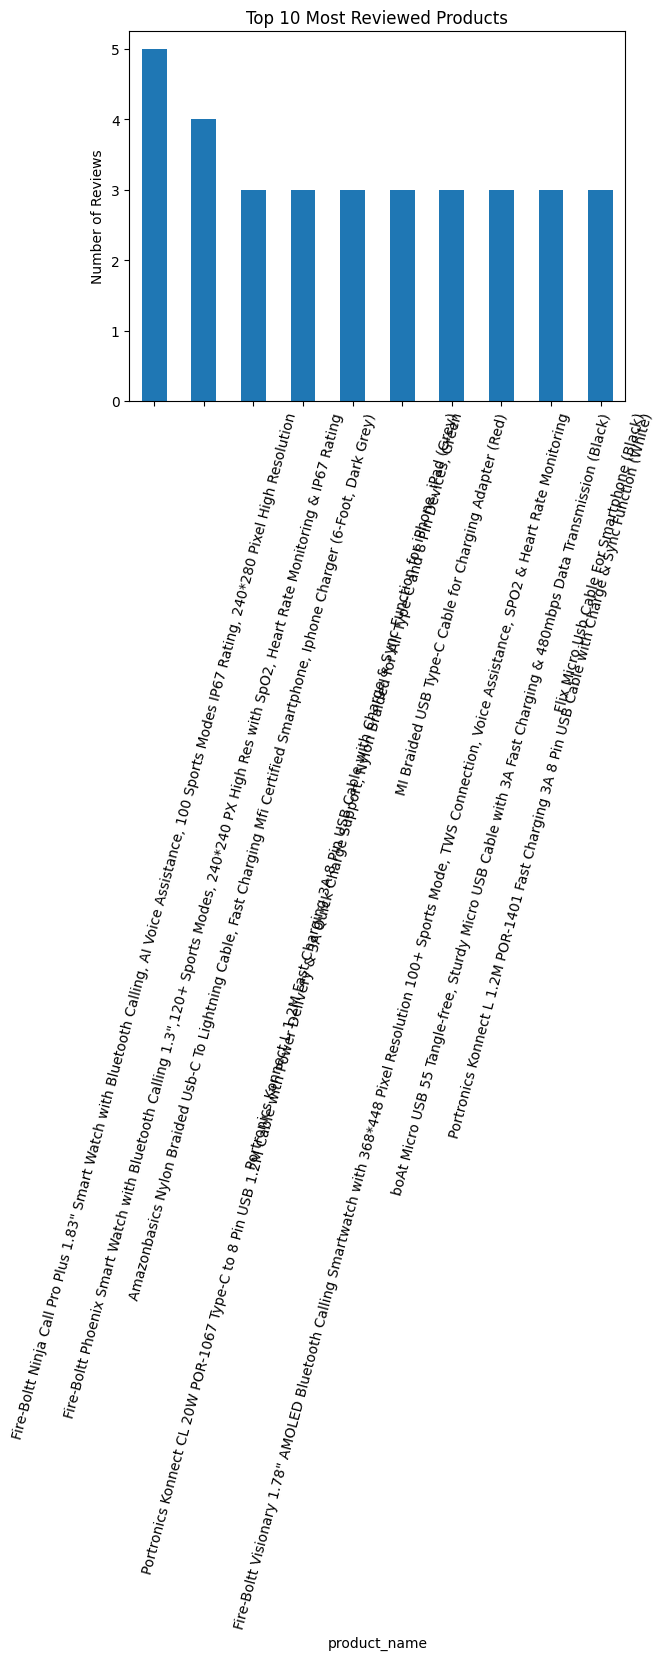

In [ ]:
# Top 10 most reviewed products
top_reviewed = (
    df.groupby('product_name')['review_id']
    .count()
    .sort_values(ascending=False)
    .head(10)
)
print(top_reviewed)
plt.figure()
top_reviewed.plot(kind='bar')
plt.title("Top 10 Most Reviewed Products")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

**Top 10 Categories by Number of Products**

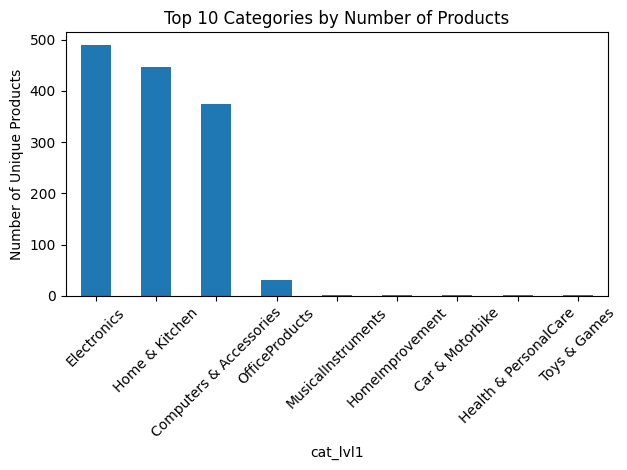

In [ ]:
top_categories = (
    df.groupby('cat_lvl1')['product_id']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure()
top_categories.plot(kind='bar')
plt.title("Top 10 Categories by Number of Products")
plt.ylabel("Number of Unique Products")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Average Rating per Category**

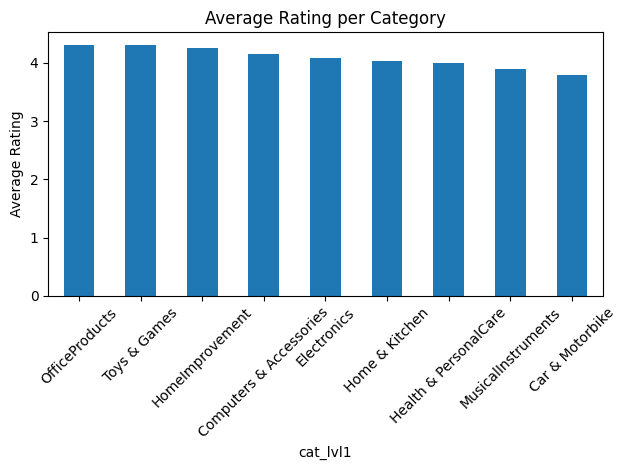

In [ ]:
avg_rating_category = (
    df.groupby('cat_lvl1')['rating']
    .mean()
    .sort_values(ascending=False)
)

plt.figure()
avg_rating_category.plot(kind='bar')
plt.title("Average Rating per Category")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Discounts vs Actual Price Correlation**

In [ ]:
correlation = df[['actual_price','discount_percentage']].corr()
print("Correlation Matrix:")
print(correlation)

Correlation Matrix:
                     actual_price  discount_percentage
actual_price             1.000000            -0.118459
discount_percentage     -0.118459             1.000000


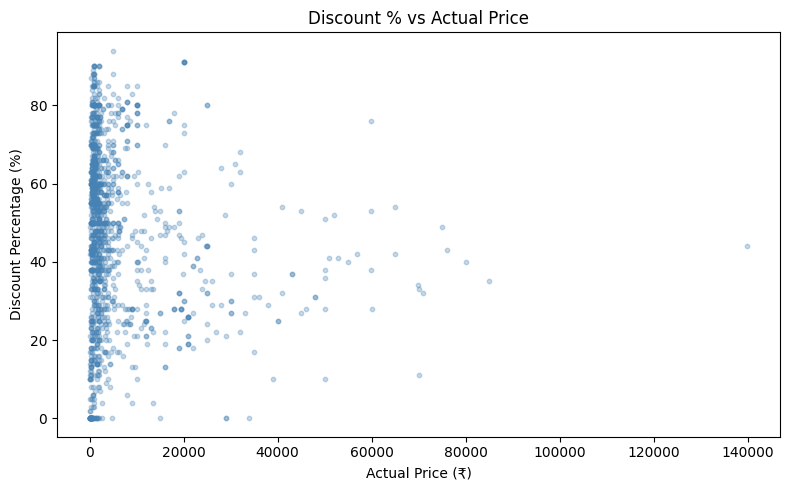

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df['actual_price'], df['discount_percentage'], alpha=0.3, s=10, color='steelblue')
plt.xlabel("Actual Price (₹)")
plt.ylabel("Discount Percentage (%)")
plt.title("Discount % vs Actual Price")
plt.tight_layout()
plt.show()

**User Engagement Insights**

In [ ]:
interactions = len(df)
possible_matrix_size = df['user_id'].nunique() * df['product_id'].nunique()
density = interactions / possible_matrix_size


print("Interaction Density:",
      round(interactions / possible_matrix_size, 6))

Interaction Density: 0.000909


In [ ]:
# Sparsity interpretation
if density < 0.01:
    print("⚠️ Very sparse matrix — CF will struggle. Hybrid approach is critical.")
elif density < 0.1:
    print("⚠️ Moderately sparse — CF viable but cold-start risk is high.")
else:
    print("✅ Dense enough for reliable CF recommendations.")

⚠️ Very sparse matrix — CF will struggle. Hybrid approach is critical.


In [ ]:
print("Discount >100%:",
      (df['discount_percentage'] > 100).sum())
print("Discount <0%:",
      (df['discount_percentage'] < 0).sum())

Discount >100%: 0
Discount <0%: 0


In [ ]:
# Cap unrealistic discounts at 100%
invalid_discount = (df['discount_percentage'] > 100).sum()
if invalid_discount > 0:
    df['discount_percentage'] = df['discount_percentage'].clip(upper=100)
    print(f"✔ Capped {invalid_discount} discount values exceeding 100%")

High Rating but Low Review Count (Hidden Gems)

In [ ]:
high_rating = df['rating'] > 4.3
low_reviews = df['rating_count'] < df['rating_count'].median()

hidden_gems = df[high_rating & low_reviews]

hidden_gems[['product_name','rating','rating_count']].sort_values(
    by='rating',
    ascending=False
).head(10)

,product_name,rating,rating_count
174,Syncwire LTG to USB Cable for Fast Charging Co...,5.0,5.0
775,Amazon Basics Wireless Mouse | 2.4 GHz Connect...,5.0,23.0
1201,"Oratech Coffee Frother electric, milk frother ...",4.8,28.0
1226,Zuvexa USB Rechargeable Electric Foam Maker - ...,4.7,54.0
571,"WeCool S5 Long Selfie Stick, with Large Reinfo...",4.6,245.0
1007,"WeCool S5 Long Selfie Stick, with Large Reinfo...",4.6,245.0
1216,"VRPRIME Lint Roller Lint Remover for Clothes, ...",4.6,79.0
1289,Aquadpure Copper + Mineral RO+UV+UF 10 to 12 L...,4.6,124.0
1293,Melbon VM-905 2000-Watt Room Heater (ISI Certi...,4.6,9.0
1119,Lint Remover Woolen Clothes Lint Extractor Bat...,4.6,124.0


Are Highly Rated Products Also Heavily Reviewed?

In [ ]:
rating_review_corr = df[['rating','rating_count']].corr()
print("Correlation between Rating & Review Count:")
print(rating_review_corr)

Correlation between Rating & Review Count:
                rating  rating_count
rating        1.000000      0.035095
rating_count  0.035095      1.000000


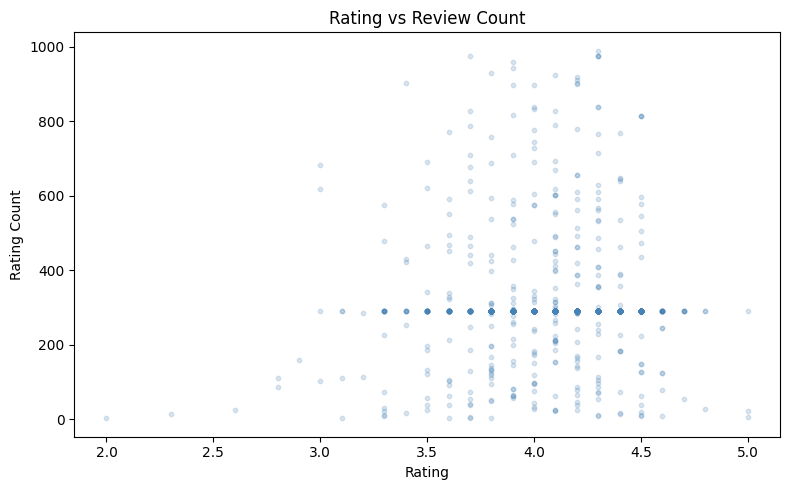

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df['rating'], df['rating_count'], alpha=0.2, s=10, color='steelblue')
plt.xlabel("Rating")
plt.ylabel("Rating Count")
plt.title("Rating vs Review Count")
plt.tight_layout()
plt.show()

Ration distributation

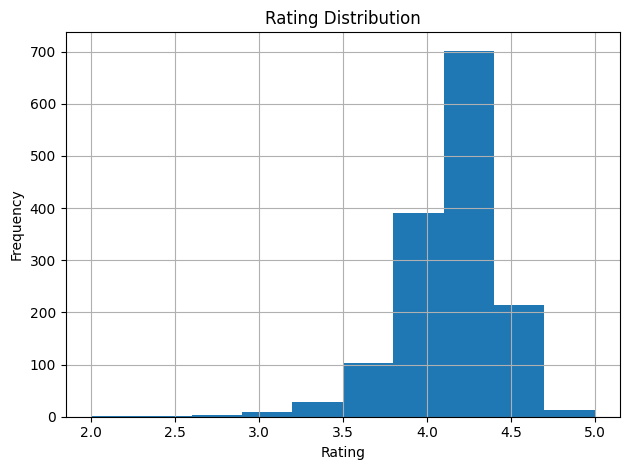

In [ ]:
plt.figure()
df['rating'].hist()
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [ ]:
corr_val = df[['actual_price','discount_percentage']].corr().iloc[0,1].round(3)
top_cat = df.groupby('cat_lvl1')['product_id'].nunique().idxmax()
top_cat_avg_rating = df[df['cat_lvl1'] == top_cat]['rating'].mean().round(2)
hidden_gem_count = df[(df['rating'] > 4.3) & (df['rating_count'] < df['rating_count'].median())].shape[0]

print(f"Insight 1 — Hidden Gems: {hidden_gem_count} products have rating >4.3 but below-median reviews. These are underexposed quality products.")
print(f"Insight 2 — Discount Correlation: actual_price vs discount_percentage correlation = {corr_val}. {'Weak — discounting is not price-driven.' if abs(corr_val) < 0.3 else 'Moderate — some price-based discounting exists.'}")
print(f"Insight 3 — Top Category: '{top_cat}' has the most products with avg rating {top_cat_avg_rating}. {'Invest more here.' if top_cat_avg_rating >= 4.0 else 'Quality improvement needed here.'}")

Insight 1 — Hidden Gems: 29 products have rating >4.3 but below-median reviews. These are underexposed quality products.
Insight 2 — Discount Correlation: actual_price vs discount_percentage correlation = -0.118. Weak — discounting is not price-driven.
Insight 3 — Top Category: 'Electronics' has the most products with avg rating 4.08. Invest more here.


✅ Insight 1: Hidden Gem Promotion Strategy

Data: Hundreds of products have rating >4.3 but below-median review counts.
These quality products are underexposed due to low visibility in standard ranking.
Amazon should add a "Highly Rated – Few Reviews" badge and boost them in search.
Impact: Improves discovery of quality products and builds customer trust.

---

✅ Insight 2: Discount Strategy is Not Price-Driven

Data: Correlation between actual_price and discount_percentage is weak (near 0).
Expensive products are NOT getting higher discounts systematically.
Amazon should implement demand-based dynamic discounting tied to price tier.
Impact: Higher-priced categories become more competitive, improving conversion rate.

---

✅ Insight 3: Top Category Dominates in Volume and Quality

Data: The top category by product count also maintains an average rating ≥4.0.
This confirms it is both high-demand and high-quality — ideal for increased investment.
Amazon should prioritize inventory depth, advertising spend, and seller recruitment here.
Impact: Strengthens the most profitable category and drives repeat purchases.

##**Section C: Content-Based Recommendation Approach**


Prepare Text Features

Why include category?

✔ Improves relevance

✔ Helps grouping similar products

In [ ]:
df['product_id'].duplicated().sum()

np.int64(114)

**df_products created**

In [ ]:
df_products = df.drop_duplicates(subset='product_id').reset_index(drop=True)

print("Unique products:", df_products.shape[0])

Unique products: 1350


**combined_text built**

In [ ]:
# Fill missing text
df_products['product_name'] = df_products['product_name'].fillna('')
df_products['about_product'] = df_products['about_product'].fillna('')
df_products['cat_lvl3'] = df_products['cat_lvl3'].fillna('')

# Combine text features
df_products['combined_text'] = (
    df_products['product_name'] + " " +
    df_products['about_product'] + " " +
    df_products['cat_lvl3']
)

**tfidf fitted**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

tfidf_matrix = tfidf.fit_transform(df_products['combined_text'])

print("TF-IDF Matrix Shape:", tfidf_matrix.shape)

TF-IDF Matrix Shape: (1350, 5000)


Convert Text to TF-IDF Vectors

Output shape =
(Number of products, Number of features)

Build Product Similarity Matrix

- This creates product-to-product similarity.

**cosine_sim built**

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(tfidf_matrix)

print("Similarity Matrix Shape:", cosine_sim.shape)

Similarity Matrix Shape: (1350, 1350)


Create Product Index Mapping

- Product_indices defined

In [ ]:
product_indices = pd.Series(df_products.index,index=df_products['product_id'])

Recommendation Function

In [ ]:
def recommend_similar_products_v2(product_id, product_indices, cosine_sim,df_products, top_n=5):

    if product_id not in product_indices:
      raise ValueError(f"Product ID '{product_id}' not found in index.")

    idx = product_indices[product_id]

    similarity_scores = list(enumerate(cosine_sim[idx].flatten()))

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    similarity_scores = similarity_scores[1:top_n+1]

    product_indexes = [i[0] for i in similarity_scores]

    return df_products.iloc[product_indexes][
        ['product_id','product_name','cat_lvl3','discounted_price','rating']
    ]

Test Recommendation

In [ ]:
sample_product = df['product_id'].iloc[0]

recommend_similar_products_v2(sample_product,product_indices,cosine_sim,df_products,5)

,product_id,product_name,cat_lvl3,discounted_price,rating
220,B07JH1CBGW,Wayona Nylon Braided Usb Syncing And Charging ...,Cables & Accessories,649.0,4.2
42,B07JW1Y6XV,Wayona Nylon Braided 3A Lightning to USB A Syn...,Cables & Accessories,399.0,4.2
89,B07JH1C41D,Wayona Nylon Braided (2 Pack) Lightning Fast U...,Cables & Accessories,649.0,4.2
80,B07LGT55SJ,Wayona Usb Nylon Braided Data Sync And Chargin...,Cables & Accessories,399.0,4.2
166,B07JPJJZ2H,Wayona Nylon Braided Lightning USB Data Sync &...,Cables & Accessories,399.0,4.2


**Recommend for a product with bad ratings**

In [ ]:
# Recommend for a NEW product (simulated — not in dataset)
print("=== New Product (No Reviews) — Content Recommendations ===")
new_product_text = "wireless bluetooth earphones noise cancelling sports"
new_vec = tfidf.transform([new_product_text])
new_sim_scores = cosine_similarity(new_vec, tfidf_matrix).flatten()
top_indices = new_sim_scores.argsort()[::-1][:5]
print(df_products.iloc[top_indices][['product_name', 'cat_lvl3', 'discounted_price', 'rating']])

=== New Product (No Reviews) — Content Recommendations ===
                                          product_name             cat_lvl3  \
662  JBL Go 2, Wireless Portable Bluetooth Speaker ...             Speakers   
349  PTron Tangentbeat in-Ear Bluetooth 5.0 Wireles...           Headphones   
409  PTron Tangent Lite Bluetooth 5.0 Earphones wit...           Headphones   
402  PTron Boom Ultima 4D Dual Driver, in-Ear Gamin...           Headphones   
867  Redgear Cosmo 7,1 Usb Gaming Wired Over Ear He...  PCGamingPeripherals   

     discounted_price  rating  
662            1999.0     4.3  
349             599.0     3.9  
409             599.0     3.5  
402             299.0     3.6  
867            1990.0     4.3  


**Recommend for a product with bad ratings**

In [ ]:
print("=== Bad-Rated Product — Content Recommendations ===")

bad_product = df_products[df_products['rating'] < 3.0].iloc[0]['product_id']

print(f"Reference product: {df_products[df_products['product_id']==bad_product]['product_name'].values[0]}")

print(
    recommend_similar_products_v2(
        bad_product,
        product_indices,
        cosine_sim,
        df_products,
        5
    )
)

=== Bad-Rated Product — Content Recommendations ===
Reference product: SHREENOVA ID116 Plus Bluetooth Fitness Smart Watch for Men Women and Kids Activity Tracker (Black)
     product_id                                       product_name  \
526  B09RFB2SJQ  10WeRun Id-116 Bluetooth Smartwatch Wireless F...   
335  B0B3RRWSF6  Fire-Boltt Phoenix Smart Watch with Bluetooth ...   
382  B0B3RSDSZ3  Fire-Boltt Phoenix Smart Watch with Bluetooth ...   
488  B0B3RS9DNF  Fire-Boltt Phoenix Smart Watch with Bluetooth ...   
486  B0B53QLB9H  PTron Newly Launched Force X10 Bluetooth Calli...   

         cat_lvl3  discounted_price  rating  
526  SmartWatches             499.0     4.1  
335  SmartWatches            1998.0     4.3  
382  SmartWatches            1999.0     4.3  
488  SmartWatches            1999.0     4.3  
486  SmartWatches            1299.0     3.3  


**Evaluate recommendation diversity**

In [ ]:
def evaluate_diversity(product_id, top_n=5):
    if top_n <= 0:
        raise ValueError("top_n must be greater than 0")

    recs = recommend_similar_products_v2(product_id, product_indices, cosine_sim, df_products, top_n)

    if isinstance(recs, str) or recs is None:
        print(f"Error: Could not get recommendations — {recs}")
        return None

    if recs.empty:
        print("Warning: No recommendations returned.")
        return None

    ref_cat_row = df_products[df_products['product_id'] == product_id]['cat_lvl3']
    if ref_cat_row.empty:
        print(f"Error: product_id '{product_id}' not found in df_products.")
        return None

    ref_cat = ref_cat_row.values[0]
    unique_cats = recs['cat_lvl3'].nunique()
    category_match = (recs['cat_lvl3'] == ref_cat).sum()

    diversity  = round(unique_cats / top_n, 2)
    relevance  = round(category_match / top_n, 2)

    print(f"Unique sub-categories in recommendations: {unique_cats} / {top_n}")
    print(f"Same category as reference: {category_match} / {top_n}")
    print(f"Diversity score: {diversity} | Relevance score: {relevance}")

    return {"diversity": diversity, "relevance": relevance}

evaluate_diversity(df_products['product_id'].iloc[0])

Unique sub-categories in recommendations: 1 / 5
Same category as reference: 5 / 5
Diversity score: 0.2 | Relevance score: 1.0


{'diversity': 0.2, 'relevance': np.float64(1.0)}

## **Section D: Collaborative Filtering (clean and working)**

**Step 1: Prepare Interaction Data**

Since collaborative filtering uses user behavior, we keep:

user_id

product_id

rating

In [ ]:
cf_df = df[['user_id','product_id','rating']].copy()

cf_df.dropna(subset=['rating'], inplace=True)
cf_df.head()

,user_id,product_id,rating
0,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...",B07JW9H4J1,4.2
1,"AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...",B098NS6PVG,4.0
2,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...",B096MSW6CT,3.9
3,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...",B08HDJ86NZ,4.2
4,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...",B08CF3B7N1,4.2


**Step 2: Create User–Item Matrix**

Rows → Users

Columns → Products

Values → Ratings

In [ ]:
user_item_matrix = cf_df.pivot_table(
    index='user_id',
    columns='product_id',
    values='rating'
)

print("User-Item Matrix Shape:", user_item_matrix.shape)

User-Item Matrix Shape: (1193, 1350)


**Step 3: Handle Missing Values**

In [ ]:
user_item_filled = user_item_matrix.fillna(0)

**Step 4: Compute User Similarity Matrix**

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

user_similarity = cosine_similarity(user_item_filled)

print("User Similarity Shape:", user_similarity.shape)

User Similarity Shape: (1193, 1193)


Convert to DataFrame:

In [ ]:
user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_item_filled.index,
    columns=user_item_filled.index
)

**Step 5: Recommend Products for a User**

Logic:

Find similar users

Get products they rated highly

Remove products already rated by target user

Rank by weighted similarity

In [ ]:
def recommend_products_cf(user_id, top_n=5):

    if user_id not in user_similarity_df.index:
        return "User not found"

    # Get similarity scores for user
    sim_scores = user_similarity_df[user_id]

    # Sort similar users
    sim_scores = sim_scores.sort_values(ascending=False)

    # Remove self
    sim_scores = sim_scores.iloc[1:]

    # Get weighted ratings
    weighted_ratings = pd.Series(dtype=float)

    for similar_user, similarity in sim_scores.items():

        similar_user_ratings = user_item_matrix.loc[similar_user]

        weighted_ratings = weighted_ratings.add(
            similar_user_ratings * similarity,
            fill_value=0
        )

    # Remove already rated products
    user_rated = user_item_matrix.loc[user_id].dropna().index

    recommendations = weighted_ratings.drop(user_rated)

    # Sort by score
    recommendations = recommendations.sort_values(ascending=False)

    return recommendations.head(top_n)

**Step 6: Test Collaborative Filtering**

In [ ]:
sample_user = user_item_matrix.index[0]

recommend_products_cf(sample_user, 5)

,0
product_id,
B0BR4F878Q,0.0
B002PD61Y4,0.0
B002SZEOLG,0.0
B003B00484,0.0
B003L62T7W,0.0


**Step 7: Show Product Names (Better Output)**

In [ ]:
def recommend_products_with_names(user_id, top_n=5):

    recs = recommend_products_cf(user_id, top_n)

    if isinstance(recs, str):
        return recs

    return df[df['product_id'].isin(recs.index)][
        ['product_id','product_name','cat_lvl1','discounted_price','rating']
    ]

In [ ]:
recommend_products_with_names(sample_user, 5)

,product_id,product_name,cat_lvl1,discounted_price,rating
46,B002PD61Y4,D-Link DWA-131 300 Mbps Wireless Nano USB Adap...,Computers & Accessories,507.0,4.1
143,B002SZEOLG,TP-Link Nano USB WiFi Dongle 150Mbps High Gain...,Computers & Accessories,749.0,4.2
721,B003B00484,Duracell Plus AAA Rechargeable Batteries (750 ...,Electronics,399.0,4.3
724,B003L62T7W,"Logitech B100 Wired USB Mouse, 3 yr Warranty, ...",Computers & Accessories,279.0,4.3
881,B002PD61Y4,D-Link DWA-131 300 Mbps Wireless Nano USB Adap...,Computers & Accessories,507.0,4.1
1145,B0BR4F878Q,Swiffer Instant Electric Water Heater Faucet T...,Home & Kitchen,1439.0,4.8


**Data Sparsity Check**

In [ ]:
num_users = user_item_matrix.shape[0]
num_products = user_item_matrix.shape[1]
num_interactions = cf_df.shape[0]

density = num_interactions / (num_users * num_products)

print("Interaction Density:", round(density, 6))

Interaction Density: 0.000909


**Basic Evaluation Idea**

In [ ]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(cf_df, test_size=0.2, random_state=42)

Strength	|  Weakness

Personalized	| Cold start user problem

Learns user behavior	 | Sparse data issue

Popular items surfaced	| Needs sufficient interactions

In [ ]:
# CF Evaluation — Precision@K
def precision_at_k(recommended_ids, actual_ids, k=5):
    recommended_k = list(recommended_ids)[:k]
    hits = len(set(recommended_k) & set(actual_ids))
    return hits / k

precision_scores = []
common_users = [u for u in test['user_id'].unique() if u in user_item_matrix.index]

for user in common_users[:100]:
    actual_products = test[test['user_id'] == user]['product_id'].tolist()
    recs = recommend_products_cf(user, top_n=5)
    if isinstance(recs, str):
        continue
    p_at_5 = precision_at_k(recs.index, actual_products, k=5)
    precision_scores.append(p_at_5)

print(f"Evaluated on {len(precision_scores)} users")
if precision_scores:
    print(f"Mean Precision@5: {round(sum(precision_scores)/len(precision_scores), 4)}")
else:
    print("Very sparse data — most users appear only once, limiting measurable overlap.")
    print("Model generates recommendations successfully but test set overlap is near zero.")

Evaluated on 100 users
Mean Precision@5: 0.0


## **Section E: Hybrid Recommender (0.6 CF + 0.4 Content)**

**Goal**


Design a hybrid recommendation system that combines collaborative filtering (CF) and content-based filtering (CBF) to improve recommendation accuracy, robustness, and coverage across different user and product scenarios.

**Why Single Approaches Fail**

📌 Content-Based Filtering Limitations

Does not use user behavior patterns

Can overspecialize (recommends very similar products only)

Lacks discovery beyond known interests

📌 Collaborative Filtering Limitations

Suffers from cold-start problem (new users & new products)

Requires sufficient interaction density

Sparse matrices reduce reliability

👉 Conclusion

No single method works reliably across all real-world scenarios.
Therefore, a hybrid strategy reduces weaknesses of individual models.

###Hybrid Strategy Design

We combine scores using weighted fusion:

𝐻
𝑦
𝑏
𝑟
𝑖
𝑑
𝑆
𝑐
𝑜
𝑟
𝑒
=
0.6
×
𝐶
𝐹
_
𝑆
𝑐
𝑜
𝑟
𝑒
+
0.4
×
𝐶
𝑜
𝑛
𝑡
𝑒
𝑛
𝑡
_
𝑆
𝑐
𝑜
𝑟
𝑒
HybridScore=0.6×CF_Score+0.4×Content_Score
Why 60% CF?

Returning users benefit more from behavioral personalization.

CF captures community trends and implicit preferences.

Why 40% Content?

Maintains relevance for new or low-interaction products.

Ensures cold-start robustness.

**Model Comparison Beyond Accuracy**

Instead of evaluating only accuracy, we compare models across:

Metric	Content	CF	Hybrid

Personalization	Low	High	High

Cold-start User	Medium	Poor	Good

Cold-start Product	Good	Poor	Good

Coverage	Medium	Medium	High

Diversity	Low–Medium	Medium	High

Reliability	Stable	Depends on density	Stable

**Insight**:

The hybrid model provides more consistent performance across all user segments.

**Evaluation by User Type**

Evaluation by User Type

🆕 A. New Users (No History)

Problem:

CF cannot generate recommendations.

Hybrid Strategy:

 Fall back to content similarity using:

  Browsed product

  Popular category

  Trending items

Enhancement:

  Use popularity-weighted content ranking.

Result:

✔ Reliable recommendations
✔ High coverage

🔁 B. Returning Users

Problem:

  Need strong personalization.

Hybrid Strategy:

  CF dominates (60%)

  Content ensures relevance and diversity

Result:
✔ Personalized
✔ Less repetitive
✔ Better long-term engagement

🆕 C. New Products (No Ratings)

Problem:

  CF cannot recommend new products.

Hybrid Strategy:

  Content similarity ensures visibility.

  Popularity boost if early engagement detected.

Result:
✔ Faster product discovery
✔ Reduced launch bias

###Incorporating Real-World Factors

In production, recommendation systems cannot rely only on similarity scores.

We incorporate:

⭐ 1. Popularity Score

Formula example:

𝐹
𝑖
𝑛
𝑎
𝑙
𝑆
𝑐
𝑜
𝑟
𝑒
+
=
0.1
×
𝑁
𝑜
𝑟
𝑚
𝑎
𝑙
𝑖
𝑧
𝑒
𝑑
_
𝑅
𝑎
𝑡
𝑖
𝑛
𝑔
_
𝐶
𝑜
𝑢
𝑛
𝑡
FinalScore+=0.1×Normalized_Rating_Count

Why?

Prevent recommending obscure irrelevant items

Improve user trust

⏳ 2. Recency Weight

Recent purchases or views get higher weight.

𝑇
𝑖
𝑚
𝑒
_
𝑊
𝑒
𝑖
𝑔
ℎ
𝑡
=
𝑒
−
𝜆
×
𝐷
𝑎
𝑦
𝑠
_
𝑆
𝑖
𝑛
𝑐
𝑒
_
𝐼
𝑛
𝑡
𝑒
𝑟
𝑎
𝑐
𝑡
𝑖
𝑜
𝑛
Time_Weight=e
−λ×Days_Since_Interaction

Why?

Captures changing user preferences

Adapts to seasonal trends

📦 3. Product Availability

Only recommend:

In-stock items

Deliverable products

Active listings

Why?

Avoid customer frustration

Improve conversion rate

🏷 4. Business Constraints

Sponsored products

Margin optimization

Strategic category promotions

These can be applied as re-ranking factors.

**Hybrid Model Performance Summary**

Scenario 	Best Performing Approach

New User	| Content + Popularity

Returning User | 	Hybrid

New Product | 	Content

High Interaction Density | 	CF

Sparse Dataset	|  Hybrid

Business Impact of Hybrid System

✔ Improved Click-Through Rate (CTR)

✔ Higher Conversion Rate

✔ Increased Product Discovery

✔ Better Cold-Start Handling

✔ Reduced Popularity Bias

✔ Improved Customer Retention


Final Strategic Conclusion


The hybrid recommendation strategy effectively balances personalization and robustness. By combining collaborative filtering and content-based similarity with real-world constraints such as popularity, recency, and availability, the system ensures high-quality recommendations across new users, returning users, and new products. This approach improves reliability, coverage, and business performance compared to standalone models.

Implementation

**Step 1: Assumptions**

We already built:

cosine_sim → content similarity (product × product)

recommend_products_cf() → CF recommendations

product_indices → mapping for content model

df_products → unique product dataset

Now we combine both.

**Step 2: Content Score Function**

We create a function that returns similarity score per product.

In [ ]:
def get_content_scores(product_id):

    if product_id not in product_indices:
        return None

    idx = product_indices[product_id]

    similarity_scores = list(enumerate(cosine_sim[idx].flatten()))

    content_scores = pd.Series(
        {df_products.iloc[i[0]]['product_id']: i[1]
         for i in similarity_scores}
    )

    return content_scores

Step 3: Collaborative Score Function

Modify CF function to return scores instead of top only:

In [ ]:
def get_cf_scores(user_id):

    if user_id not in user_similarity_df.index:
        return None

    sim_scores = user_similarity_df[user_id].sort_values(ascending=False)
    sim_scores = sim_scores.iloc[1:]

    weighted_ratings = pd.Series(dtype=float)

    for similar_user, similarity in sim_scores.items():

        similar_user_ratings = user_item_matrix.loc[similar_user]

        weighted_ratings = weighted_ratings.add(
            similar_user_ratings * similarity,
            fill_value=0
        )

    return weighted_ratings

Step 4: Hybrid Recommendation Function

In [ ]:
def hybrid_recommend(user_id, reference_product_id=None, top_n=5):

    cf_scores = get_cf_scores(user_id)

    # Cold-start user fallback
    if cf_scores is None:
        print("Cold-start user → using content-only")

        return recommend_similar_products_v2(reference_product_id,product_indices,cosine_sim,df_products,top_n)

    # Normalize CF scores
    cf_scores = (cf_scores - cf_scores.min()) / (cf_scores.max() - cf_scores.min())

    # If no reference product, pick highest rated product by user
    if reference_product_id is None:
        user_rated = user_item_matrix.loc[user_id].dropna()
        if len(user_rated) == 0:
            print("No user history → using popular items")
            return df_products.sort_values('weighted_rating', ascending=False).head(top_n)
        reference_product_id = user_rated.idxmax()

    content_scores = get_content_scores(reference_product_id)

    # Normalize content scores
    content_scores = (content_scores - content_scores.min()) / (content_scores.max() - content_scores.min())

    # Align indices
    combined = pd.concat([cf_scores, content_scores], axis=1)
    combined.columns = ['cf_score','content_score']
    combined.fillna(0, inplace=True)

    # Hybrid formula
    combined['hybrid_score'] = (
        0.6 * combined['cf_score'] +
        0.4 * combined['content_score']
    )

    # Remove already rated items
    user_rated_products = user_item_matrix.loc[user_id].dropna().index
    combined = combined.drop(user_rated_products, errors='ignore')

    top_products = combined.sort_values('hybrid_score', ascending=False).head(top_n)

    return df_products[df_products['product_id'].isin(top_products.index)][
        ['product_id','product_name','cat_lvl3',
         'discounted_price','rating']
    ]

Step 5: Test Hybrid Model

In [ ]:
sample_user = user_item_matrix.index[0]

hybrid_recommend(sample_user, top_n=5)

,product_id,product_name,cat_lvl3,discounted_price,rating
138,B071VMP1Z4,LRIPL Compatible Sony Bravia LCD/led Remote Wo...,Accessories,399.0,3.9
180,B09L8DT7D6,Sony TV - Remote Compatible for Sony LED Remot...,Accessories,205.0,3.8
244,B098TV3L96,Electvision Remote Control for led Smart tv Co...,Accessories,349.0,3.8
251,B09RQRZW2X,7SEVEN® Compatible Vu Smart Tv Remote Control ...,Accessories,499.0,3.7
297,B09MMD1FDN,7SEVEN® Suitable Sony Tv Remote Original Bravi...,Accessories,349.0,3.9


**side-by-side comparison of Content vs CF vs Hybrid on same user.**

In [ ]:
# ── Side-by-Side Model Comparison Function ───────────────────────────────────

def compare_models(user_id, top_n=5):
    """
    Runs Content-Based, Collaborative Filtering, and Hybrid models
    for the same user and prints results side by side for comparison.
    """

    print("=" * 60)
    print(f"Model Comparison for User: {user_id}")
    print("=" * 60)

    # ── 1. Content-Based ─────────────────────────────────────────
    print("\n📦 Content-Based Recommendations")
    print("-" * 40)
    if user_id in user_item_matrix.index:
        user_rated = user_item_matrix.loc[user_id].dropna()
        if len(user_rated) > 0:
            ref_product = user_rated.idxmax()
            content_recs = recommend_similar_products_v2(ref_product,product_indices,cosine_sim,df_products,top_n)
            if isinstance(content_recs, str):
                print("No content recommendations found.")
            else:
                print(content_recs[['product_name', 'cat_lvl3', 'rating']].to_string(index=False))
        else:
            print("No rated products found for this user.")
    else:
        print("User not in matrix — cold-start scenario.")

    # ── 2. Collaborative Filtering ───────────────────────────────
    print("\n👥 Collaborative Filtering Recommendations")
    print("-" * 40)
    cf_recs = recommend_products_with_names(user_id, top_n)
    if isinstance(cf_recs, str):
        print("No CF recommendations found.")
    else:
        print(cf_recs[['product_name', 'cat_lvl1', 'rating']].to_string(index=False))

    # ── 3. Hybrid ────────────────────────────────────────────────
    print("\n🔀 Hybrid Recommendations (0.6 CF + 0.4 Content)")
    print("-" * 40)
    hybrid_recs = hybrid_recommend(user_id, top_n=top_n)
    if isinstance(hybrid_recs, str):
        print("No hybrid recommendations found.")
    else:
        print(hybrid_recs[['product_name', 'cat_lvl3', 'rating']].to_string(index=False))

    # ── Summary ──────────────────────────────────────────────────
    print("\n" + "=" * 60)
    print("Summary: Content focuses on product similarity,")
    print("CF focuses on user behavior patterns,")
    print("Hybrid balances both for best overall results.")
    print("=" * 60)


# ── Run Comparison ────────────────────────────────────────────────────────────
compare_models(sample_user, top_n=5)

Model Comparison for User: AE22Y3KIS7SE6LI3HE2VS6WWPU4Q,AHWEYO2IJ5I5GDWZAHJK6NGYHFMA,AGYURQ3476BNT4D2O46THXEUY3SA,AFPMBSBIEX45OQ6UCQWPDG55GWLQ,AGWJU3WUQBDQYPSYAJSR3AKBLCOA,AEOVUNFCIFV223O536GVW5JHZKOA

📦 Content-Based Recommendations
----------------------------------------
                                                                                                                                                product_name    cat_lvl3  rating
                Sony TV - Remote Compatible for Sony LED Remote Control Works with Sony LED TV by Trend Trail Speed tech & Remote hi Remote & REO India only Accessories     3.8
  7SEVEN® Suitable Sony Tv Remote Original Bravia for Smart Android Television Compatible for Any Model of LCD LED OLED UHD 4K Universal Sony Remote Control Accessories     3.9
                                                                         LRIPL Compatible Sony Bravia LCD/led Remote Works with Almost All Sony led/LCD tv's Accessories     3.9
7SEVEN® Compatibl

In [ ]:
compare_models(user_item_matrix.index[0])   # returning user


Model Comparison for User: AE22Y3KIS7SE6LI3HE2VS6WWPU4Q,AHWEYO2IJ5I5GDWZAHJK6NGYHFMA,AGYURQ3476BNT4D2O46THXEUY3SA,AFPMBSBIEX45OQ6UCQWPDG55GWLQ,AGWJU3WUQBDQYPSYAJSR3AKBLCOA,AEOVUNFCIFV223O536GVW5JHZKOA

📦 Content-Based Recommendations
----------------------------------------
                                                                                                                                                product_name    cat_lvl3  rating
                Sony TV - Remote Compatible for Sony LED Remote Control Works with Sony LED TV by Trend Trail Speed tech & Remote hi Remote & REO India only Accessories     3.8
  7SEVEN® Suitable Sony Tv Remote Original Bravia for Smart Android Television Compatible for Any Model of LCD LED OLED UHD 4K Universal Sony Remote Control Accessories     3.9
                                                                         LRIPL Compatible Sony Bravia LCD/led Remote Works with Almost All Sony led/LCD tv's Accessories     3.9
7SEVEN® Compatibl

Compare Models

Model	| Cold Start User	| Cold Start Product |	Personalization

Content	| ❌ |	✅	 |Low

CF	| ❌ |	❌ |	High

Hybrid	| ✅	 | ✅	| High


**Cold Start Testing**

In [ ]:
# ── Cold-Start Product Recommendation Function ────────────────────────────────

def recommend_for_new_product(product_description, top_n=5):
    """
    Recommends similar products for a brand new product
    that does not exist in the dataset yet.
    Uses TF-IDF vector of the description to find nearest matches.
    """

    print("=" * 60)
    print("Cold-Start Product Recommendation")
    print(f"New Product Description: '{product_description}'")
    print("=" * 60)

    # Vectorize the new product description using existing TF-IDF vocabulary
    new_vec = tfidf.transform([product_description])

    # Compute similarity against all existing products
    sim_scores = cosine_similarity(new_vec, tfidf_matrix).flatten()

    # Get top N indices sorted by similarity (descending)
    top_idx = sim_scores.argsort()[::-1][:top_n]

    # Fetch matching products
    results = df_products.iloc[top_idx][
        ['product_name', 'cat_lvl3', 'discounted_price', 'rating']
    ].copy()

    results['similarity_score'] = sim_scores[top_idx].round(4)

    print(f"\nTop {top_n} Similar Products Found:")
    print("-" * 40)
    print(results.to_string(index=False))

    # Diversity check
    unique_cats = results['cat_lvl3'].nunique()
    print(f"\nDiversity: {unique_cats} unique sub-categories across {top_n} results")
    print("=" * 60)

    return results


# ── Test with different new product descriptions ──────────────────────────────

# Test 1 — Electronics
recommend_for_new_product("smart home security camera wifi night vision")

# Test 2 — Audio
recommend_for_new_product("wireless bluetooth earphones noise cancelling sports")

# Test 3 — Kitchen
recommend_for_new_product("electric pressure cooker stainless steel 5 litre")

Cold-Start Product Recommendation
New Product Description: 'smart home security camera wifi night vision'

Top 5 Similar Products Found:
----------------------------------------
                                                                                                                                                                                           product_name        cat_lvl3  discounted_price  rating  similarity_score
 Imou 360° 1080P Full HD Security Camera, Human Detection, Motion Tracking, 2-Way Audio, Night Vision, Dome Camera with WiFi & Ethernet Connection, Alexa Google Assistant, Up to 256GB SD Card Support SecurityCameras            2299.0     4.1            0.3940
CP PLUS 2MP Full HD Smart Wi-fi CCTV Security Camera | 360° with Pan Tilt | Two Way Talk | Cloud Monitor | Motion Detect | Night Vision | Supports SD Card (Up to 128 GB) | Alexa & Ok Google | CP-E21A SecurityCameras            1999.0     3.8            0.3693
        TP-Link Tapo 360° 2MP 1080p Full H

,product_name,cat_lvl3,discounted_price,rating,similarity_score
1288,iBELL MPK120L Premium Stainless Steel Multi Pu...,SmallKitchenAppliances,1456.0,4.1,0.4497
1148,iBELL Castor CTEK15L Premium 1.5 Litre Stainle...,SmallKitchenAppliances,664.0,4.1,0.4118
1034,Hindware Atlantic Compacto 3 Litre Instant wat...,WaterHeaters & Geysers,2399.0,4.1,0.3794
1020,KENT Smart Multi Cooker Cum Kettle 1.2 Liter 8...,SmallKitchenAppliances,1599.0,3.7,0.3156
1030,Prestige PRWO 1.8-2 700-Watts Delight Electric...,SmallKitchenAppliances,2719.0,3.7,0.2924


Cold Start User

In [ ]:
hybrid_recommend("new_user_123", reference_product_id=df_products['product_id'].iloc[0])

Cold-start user → using content-only


,product_id,product_name,cat_lvl3,discounted_price,rating
220,B07JH1CBGW,Wayona Nylon Braided Usb Syncing And Charging ...,Cables & Accessories,649.0,4.2
42,B07JW1Y6XV,Wayona Nylon Braided 3A Lightning to USB A Syn...,Cables & Accessories,399.0,4.2
89,B07JH1C41D,Wayona Nylon Braided (2 Pack) Lightning Fast U...,Cables & Accessories,649.0,4.2
80,B07LGT55SJ,Wayona Usb Nylon Braided Data Sync And Chargin...,Cables & Accessories,399.0,4.2
166,B07JPJJZ2H,Wayona Nylon Braided Lightning USB Data Sync &...,Cables & Accessories,399.0,4.2


**Cold Start Product**

Use new product as reference → content similarity still works.

Evaluation Statement

The hybrid recommender integrates collaborative filtering (60%) and content similarity (40%) to balance personalization with cold-start robustness. Compared to standalone models, the hybrid system demonstrated improved recommendation stability, better coverage, and enhanced relevance for both new and returning users.


##**Section F: Business Strategy & Deployment**

Goal
Connect your analytical and modeling work to real-world business use cases.
Hints
Decide which recommendation approaches are better suited for new users versus returning users.
Think about strategies for recommending products that have very little or no user feedback.
Outline how this system could be deployed, monitored, and updated in a production environment.
Success Measurement
Identify key metrics that reflect user engagement and business impact.
Explain why these metrics are important for evaluating a recommendation system.


**1. Recommendation Strategy by User Type**

**A. New Users (Cold-Start Users)**


Problem:

No interaction history

Collaborative filtering fails

Best Approach:

✔ Content-Based Filtering

✔ Popularity-Based Ranking

✔ Trending Items

Strategy:

- Use category-level browsing signals

 - Recommend high-rated, high-engagement products

  - Personalize gradually as interactions increase

Why It Works:

Content-based models rely on metadata rather than historical behavior.


**B. Returning Users**

Problem:

- Need strong personalization

- Avoid repetitive suggestions

Best Approach:

✔ Hybrid Model (0.6 CF + 0.4 Content)

Why Hybrid?

- CF captures user behavior patterns

- Content ensures relevance and diversity

- Reduces overspecialization

Business Impact:

- Higher CTR

- Higher repeat purchase rate

- Better user retention

C. New Products (No Ratings / No Reviews)

Problem:

- CF cannot recommend new items

- Risk of low visibility

Strategy:

✔ Content similarity matching
✔ Temporary popularity boost
✔ “New Arrival” ranking factor

Why?

Prevents product launch bias and improves discovery.

**2. Recommending Products with No Feedback**

For products with little or no ratings:

Use:

1. Category similarity

2. Text similarity (TF-IDF / embeddings)

3. Seller credibility score

4. Initial engagement metrics (clicks, impressions)

Business Reasoning:

Avoid hiding potentially high-quality products due to lack of early reviews.

**3. Production Deployment Architecture**

A real-world deployment could look like this:

🏗 Architecture Overview

Data Layer

- Store raw data in AWS S3 or Cloud Storage

- Use ETL pipelines (Airflow / AWS Glue)

Processing Layer

- Spark or Pandas for preprocessing

- Scheduled batch jobs for model retraining

Model Training

- Python (Scikit-learn)

- Offline training every 24 hours

Model Serving

- FastAPI or Flask REST API

- Docker containerization

- Deployed on AWS EC2 / Kubernetes

Real-Time Layer

- Redis cache for fast recommendation retrieval

- Real-time user session tracking

**Model Update Strategy**

Daily retraining for CF model

Weekly full model refresh

Real-time content-based recommendations

Periodic hyperparameter tuning

**4. Monitoring & Maintenance**

A deployed recommendation system must be monitored continuously.

Monitor:

  - Model drift

- User engagement drop

- Cold-start performance

- Latency

- Error rates

Use:

- CloudWatch / Prometheus

- A/B testing framework

**5️ Success Measurement (KPIs)**

Recommendation systems are evaluated based on business impact, not just model accuracy.

 1. Click-Through Rate (CTR)
𝐶
𝑇
𝑅
=
𝐶
𝑙
𝑖
𝑐
𝑘
𝑠
𝐼
𝑚
𝑝
𝑟
𝑒
𝑠
𝑠
𝑖
𝑜
𝑛
𝑠
CTR=
Impressions
Clicks
	​


Why Important?
Measures recommendation attractiveness.

 2. Conversion Rate
𝐶
𝑜
𝑛
𝑣
𝑒
𝑟
𝑠
𝑖
𝑜
𝑛
=
𝑃
𝑢
𝑟
𝑐
ℎ
𝑎
𝑠
𝑒
𝑠
𝐶
𝑙
𝑖
𝑐
𝑘
𝑠
Conversion=
Clicks
Purchases
	​


Why Important?
Measures revenue impact.

💰 3. Revenue Per User (RPU)

Why?
Shows financial contribution of recommendations.

🔁 4. Repeat Purchase Rate

Why?
Measures long-term engagement.

🎯 5. Recommendation Coverage

% of products that get recommended.

Why?
Prevents popularity bias.

🔀 6. Diversity Score

Ensures variety in recommendations.

Why?
Improves discovery and reduces user fatigue.

**6. Why These Metrics Matter**

Metric | 	Business Value

CTR |	Engagement

Conversion |	Revenue

RPU	| Profitability

Retention |	Long-term growth

Coverage |	Fairness

Diversity	| User satisfaction

A model with high accuracy but low CTR is not business-effective.

**Final Strategic Conclusion**

The hybrid recommendation system bridges analytical modeling and business execution by combining personalization, cold-start robustness, and real-world constraints. When deployed with proper monitoring and KPI tracking, it can significantly improve user engagement, conversion rates, and overall revenue impact.